### Question 2: Newton's method

Program Newton's method using backtracking line search and minimize the Rosenbrock function. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
a,b = 1,100    # parameters for Rosenbrock function
f = lambda x,y: (a-x)**2+b*(y-x**2)**2
Df = lambda x,y: np.array([2*(x-a)-4*b*x*(y-x**2),
                           2*b*(y-x**2)])
D2f = lambda x,y: np.array([[2-4*b*y+12*b*x**2,-4*b*x],
                            [-4*b*x,2*b]])

x0,y0 = 1.2,1.2    # initial point for all methods

In [8]:
%%time
x,y = x0,y0    # initial point
path_Newton = [[x,y]]
tol = 1e-7            # stop when gradient is smaller than this amount
max_steps = 10000     # Maximum number of steps to run the iteration
rho = 0.75            # rho for backtracking
i=0                   # iteration count
dx = Df(x,y)          # current gradient
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -np.linalg.solve(D2f(x,y),dx)  # faster to solve a system than manually invert

    alpha = 1 # no backtracking necessary, alpha=1 in Newton's method
    
    xnew,ynew = x + alpha*pk[0], y + alpha*pk[1]
    path_Newton.append([xnew,ynew])
    x,y = xnew,ynew
    dx = Df(x,y)
    i += 1

path_Newton=np.array(path_Newton)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 5 iterations, approximate minimum is 1.874777245064311e-27 at (1.0000000000000433, 1.0000000000000866)
CPU times: user 1.36 ms, sys: 241 µs, total: 1.6 ms
Wall time: 1.46 ms


In [9]:
 print(path_Newton) #step length at each iteration

[[1.2        1.2       ]
 [1.19591837 1.43020408]
 [1.00065062 0.96317217]
 [1.00057519 1.00115071]
 [1.         0.99999967]
 [1.         1.        ]]


In [2]:
import numpy as np 
from numpy.linalg import norm 
import matplotlib.pyplot as plt 

In [14]:
def newton_method(objFunc, gradObjFunc, hessianFunc, x0, tol, maxIter):                      
    path      = [x0]
    k         = 0
    xk        = x0    
    pk        = -np.linalg.solve(hessianFunc(xk),gradObjFunc(xk))        
    while norm(gradObjFunc(xk)) > tol and k <= maxIter:        
        #alpha = backtracking(objFunc, gradObjFunc, xk, pk, alpha0, c1, 0.9)      
        xk  = xk +  pk 
        pk  = -np.linalg.solve(hessianFunc(xk), gradObjFunc(xk))
        k   = k + 1
        path.append(xk)

    path = np.array(path) # convert to array
        
    if norm(pk) <= tol:
        print("Found the minimizer at {x} with {iter} iterations  successfully, gradient's norm is {nrm}.".format(x=xk,iter=k,nrm=norm(pk)))
    else:
        print("Unable to locate minimizer within maximum iterations, last position is at {x}, gradient's norm is {nrm}".format(x=xk,nrm=norm(pk)))        
    return xk, k, path

In [15]:
def RBObjFunc(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2
def RBGradObjFunc(x):
    return np.array([-400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0]),
                     200 * (x[1] - x[0]**2)])
def RBHessianFunc(x):
    return np.matrix([[-400*(x[1] - 3*x[0]**2) + 2, -400 * x[0]], 
                      [-400 * x[0], 200]])

In [16]:
#initialize, input parameters
x0      = np.array([1.2, 1.2]) 
tol     = 1e-8 
maxIter = 1e6

In [17]:
x_2, iter_2, path_2 = newton_method(RBObjFunc, RBGradObjFunc, RBHessianFunc, x0, tol, maxIter)

Found the minimizer at [1. 1.] with 5 iterations  successfully, gradient's norm is 9.68188319766514e-14.


In [20]:
print(path_2) ##step length at each iteration

[[1.2        1.2       ]
 [1.19591837 1.43020408]
 [1.00065062 0.96317217]
 [1.00057519 1.00115071]
 [1.         0.99999967]
 [1.         1.        ]]


### Question 3

Program SR-1, DFP and BFGS with exact line search to minimize the Rosenbrock function 

#### SR-1 algorithm with exact line search

In [3]:
a,b = 1,100    # parameters for Rosenbrock function
f = lambda x,y: (a-x)**2+b*(y-x**2)**2
Df = lambda x,y: np.array([2*(x-a)-4*b*x*(y-x**2),
                           2*b*(y-x**2)])
D2f = lambda x,y: np.array([[2-4*b*y+12*b*x**2,-4*b*x],
                            [-4*b*x,2*b]])

x0,y0 = 1.2,1.2    # initial point for all methods

In [4]:
def WolfeI(alpha,f,x,dx,p,c1=0.1):
    '''Return True/False if Wolfe condition I is satisfied for the given alpha'''
    LHS = f(x[0]+alpha*p[0], x[1]+alpha*p[1])
    RHS = f(x[0],x[1])+c1*alpha*np.dot(dx,p)
    return LHS <= RHS

In [5]:
%%time
x,y = x0,y0    # initial point
path_SR1 = [[x,y]]
tol = 1e-7            # stop when gradient is smaller than this amount
max_steps = 10000     # Maximum number of steps to run the iteration
i=0                   # iteration count
skips = 0             # keep track of how many times SR1 update is skipped
rho = 0.75            # rho for backtracking
H = np.eye(2)         # initial inverse Hessian is identity
dx = Df(x,y)          # current gradient
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -H@dx
    
    # backtracking
    alpha = 1
    while not WolfeI(alpha,f,np.array([x,y]),dx,pk) and alpha>1e-5:  # lower limit to prevent small steps, similar to Wolfe II
        alpha *= rho
                
    xnew,ynew = x + alpha*pk[0], y + alpha*pk[1]
    path_SR1.append([xnew,ynew])
    
    # secant variables
    sk = alpha*pk         # x_{k+1}-x_k
    yk = Df(xnew,ynew)-dx # Df_{k+1}-Df_k
    
    # SR1 update
    vec = sk-H@yk     # @ is mATrix multiplication
    denom = vec@yk    # computes dot product if two vectors
#     print('Denominator is ',denom)   # uncomment this to do a little inspection
    if abs(denom)>1e-8*np.linalg.norm(vec)*np.linalg.norm(yk):
        # only update if denominator doesn't vanish
        H += np.outer(vec,vec)/denom    # outer product of two vectors works better than a@b.T, which requires reshaping
    else:
        # if denominator vanishes, alert the user
        skips += 1
        if skips<50:
            # set limit so we don't print too much
            print('Skipping SR1 update in iteration',i,'. Denominator is ',denom)
        elif skips==50:
            print('Reached maximum number of skips; breaking loop now.')
            break

    x,y = xnew,ynew
    dx = Df(x,y)
    i += 1

path_SR1=np.array(path_SR1)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 22 iterations, approximate minimum is 2.79111443209922e-20 at (1.0000000001535738, 1.0000000003005702)
CPU times: user 8.57 ms, sys: 3.59 ms, total: 12.2 ms
Wall time: 8.77 ms


#### DFP with exact line search

In [6]:
%%time
x,y = x0,y0    # initial point
path_DFP = [[x,y]]
tol = 1e-7            # stop when gradient is smaller than this amount
max_steps = 10000     # Maximum number of steps to run the iteration
i=0                   # iteration count
rho = 0.75            # rho for backtracking
H = np.eye(2)         # initial inverse Hessian is identity
dx = Df(x,y)          # current gradient
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -H@dx   # -H * gradient
    
    # backtracking
    alpha = 1
    while not WolfeI(alpha,f,np.array([x,y]),dx,pk) and alpha>1e-5:  # lower limit to prevent small steps, similar to Wolfe II
        alpha *= rho
        
    xnew,ynew = x + alpha*pk[0], y + alpha*pk[1]
    path_DFP.append([xnew,ynew])
    
    # secant variables
    sk = alpha*pk         # x_{k+1}-x_k   x_{k+1} = x_k + alpha * pk
    yk = Df(xnew,ynew)-dx # Df_{k+1}-Df_k  
    
    # DFP update
    vec = H@yk # @ is matrix multiplication
    denom1 = yk@sk
    denom2 = yk@vec
    H += np.outer(sk,sk)/denom1 - np.outer(vec,vec)/denom2 # np.outer(vec, vec) = vec * vec^T, or vec@vec.T 

    x,y = xnew,ynew
    dx = Df(x,y)
    i += 1

path_DFP=np.array(path_DFP)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 29 iterations, approximate minimum is 2.1043166666309574e-20 at (1.000000000121387, 1.0000000002348313)
CPU times: user 5.81 ms, sys: 888 µs, total: 6.69 ms
Wall time: 5.94 ms


#### BFGS with exact line search

In [7]:
%%time
x,y = x0,y0    # initial point
path_BFGS = [[x,y]]
tol = 1e-7            # stop when gradient is smaller than this amount
max_steps = 10000     # Maximum number of steps to run the iteration
i=0                   # iteration count
rho = 0.75            # rho for backtracking
H = np.eye(2)         # initial inverse Hessian is identity
dx = Df(x,y)          # current gradient
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -H@dx
    
    # backtracking
    alpha = 1
    while not WolfeI(alpha,f,np.array([x,y]),dx,pk) and alpha>1e-5:  # lower limit to prevent small steps, similar to Wolfe II
        alpha *= rho
        
    xnew,ynew = x + alpha*pk[0], y + alpha*pk[1]
    path_BFGS.append([xnew,ynew])
    
    # secant variables
    sk = alpha*pk         # x_{k+1}-x_k
    yk = Df(xnew,ynew)-dx # Df_{k+1}-Df_k
    
    # BFGS update
    vec = H@yk
    denom = yk@sk
    H += (denom+vec@yk)*np.outer(sk,sk)/denom**2 - (np.outer(vec,sk)+np.outer(sk,vec))/denom

    x,y = xnew,ynew
    dx = Df(x,y)
    i += 1

path_BFGS=np.array(path_BFGS)
print(f'After {i} iterations, approximate minimum is {f(x,y)} at {x,y}')

After 19 iterations, approximate minimum is 9.369407698263574e-18 at (1.000000003046648, 1.0000000060637422)
CPU times: user 5.09 ms, sys: 750 µs, total: 5.84 ms
Wall time: 5.16 ms


Another method: 

In [1]:
import numpy as np
from numpy.linalg import norm, solve, multi_dot
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
def objective_func(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2
def grad_objective_func(x):
    return np.array([-400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0]),
                     200 * (x[1] - x[0]**2)])

In [2]:
tol = 1e-8
def exact_line_search_quasi_newton(update_method, x0, H0):
    k = 0
    xcoords = [x0[0]]
    ycoords = [x0[1]]
    x_k = x0 
    H_k = H0 
    g_k = grad_objective_func(x_k)
    while norm(g_k) > tol:
        p_k = -np.matmul(H_k, g_k)                # search direction
   
        def subproblem1D(alpha):                  # exact line search
            return objective_func(x_k + alpha * p_k)
        
        res = minimize_scalar(subproblem1D)
        alpha_k = res.x      
        s_k     = alpha_k * p_k                   # s_k = x_{k+1} - x_k 
        g_k1    = grad_objective_func(x_k + s_k)  # gk1 is g_{k+1}
        y_k     = g_k1 - g_k                      # y_k = g_{k+1} - g_(k)
        
        k = k + 1                                 # increment
        H_k = update_method(H_k, s_k, y_k).A      # .A transforms       
        #matrix  to ndarray 
        x_k = x_k + s_k 
        g_k = g_k1
        
        xcoords.append(x_k[0])
        ycoords.append(x_k[1])
        
    return x_k, k, norm(g_k), xcoords, ycoords

In [3]:
def BFGS(H, s_k, y_k):
    rho = 1.0 / np.dot(s_k, y_k)
    I = np.eye(len(s_k))
    A = I - rho * (np.matrix(s_k).T * np.matrix(y_k) )
    B = np.matrix(s_k).T * np.matrix(s_k) * rho
    z = s_k - np.dot(H, y_k) 
    H = A * H * A.T + B 
    return H

In [4]:
x0 = np.array([1.2, -1])
H0 = np.eye(2)
x, iter_number, err, xcoords, ycoords = exact_line_search_quasi_newton(BFGS, x0, H0)

In [5]:
print(np.array(xcoords))
print(np.array(ycoords))

[ 1.2        -0.19518489 -0.05573864  0.0184298   0.14038898  0.57809269
  0.57239635  0.69101558  0.84136111  0.83652146  0.91585018  0.99748087
  1.00472313  0.99984712  0.99998605  1.00000001  1.        ]
[-1.         -0.41887144  0.00644613 -0.02258161 -0.01694221  0.32307008
  0.32461948  0.46310253  0.69601128  0.69905818  0.832939    0.99687019
  1.00966289  0.99973669  0.99997166  1.00000002  1.        ]


In [6]:
print(iter_number)

16


#### Question 1

Part b

In [19]:
import numpy as np
import matplotlib.pyplot as plt
alpha = lambda x,y: ((x-1)**2+4*(2*y-1)**2)/(2*(x-1)**2+32*(2*y-1)**2)

x,y= 4,1
print(f'At {x}, {y}\nalpha={alpha(x,y)}') # random point in [0,5]x[0,5]

At 4, 1
alpha=0.26


In [20]:
# define the function
g = lambda x,y: (x-1)**2 + (2*y-1)**2
# define derivatives of f to make the gradient
Dg = lambda x,y: np.array([2*(x-1), 4*(2*y-1)])

Initial x=[4 1]
In iteration 1, alpha=0.1625, and newx=[ 2.44 -0.04]
In iteration 2, alpha=0.25999999999999995, and newx=[1.972 0.662]
In iteration 3, alpha=0.16250000000000003, and newx=[1.46656 0.32504]
In iteration 4, alpha=0.25999999999999973, and newx=[1.314928 0.552488]
In iteration 5, alpha=0.16250000000000014, and newx=[1.15116544 0.44331296]
In iteration 6, alpha=0.25999999999999995, and newx=[1.10203667 0.51700611]
In iteration 7, alpha=0.16250000000000012, and newx=[1.0489776 0.4816334]
In iteration 8, alpha=0.2600000000000012, and newx=[1.03305988 0.50550998]
In iteration 9, alpha=0.1624999999999994, and newx=[1.01586874 0.49404922]
In iteration 10, alpha=0.2600000000000036, and newx=[1.0107114  0.50178523]
In iteration 11, alpha=0.1624999999999971, and newx=[1.00514147 0.49807195]
In iteration 12, alpha=0.26000000000001106, and newx=[1.00347049 0.50057842]
In iteration 13, alpha=0.162499999999994, and newx=[1.00166584 0.49937531]
In iteration 14, alpha=0.26, and newx=[1.00

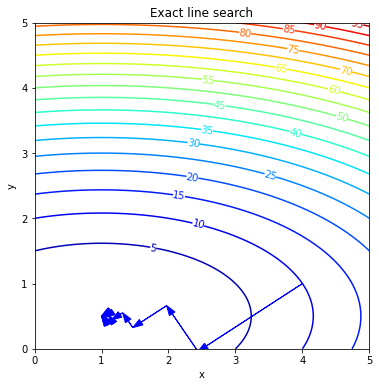

CPU times: user 148 ms, sys: 8.87 ms, total: 156 ms
Wall time: 154 ms


In [21]:
%%time
# plot the figure first
plt.figure(figsize=(6, 6))
X = np.linspace(0,5,300)  # 300 evenly spaced points on x-axis [0,5]
Y = np.linspace(0,5,300)  # 300 evenly spaced points on y-axis [0,5]
Xmesh, Ymesh = np.meshgrid(X,Y)  # 300x300 grid of points defined by X and Y above
Z = g(Xmesh,Ymesh)
CS = plt.contour(Xmesh, Ymesh, Z, 20, cmap='jet')
plt.clabel(CS,inline_spacing=0,fmt='%d')
plt.axis([0,5,0,5])
plt.xlabel('x')
plt.ylabel('y')

x0 = np.array([4,1])  # initial point randomly chosen
x = x0.copy()
print(f'Initial x={x}')
dx = np.array([np.inf,np.inf]) # initial large gradient so while loop runs
tol = 1e-3            # stop when gradient is smaller than this amount
max_steps = 100       # Maximum number of steps to run the iteration
i=0                   # iteration count
while np.linalg.norm(dx)>tol and i<max_steps:
    dx = Dg(x[0],x[1])
    # new value of x
    xnew = x - alpha(x[0],x[1])*dx # note alpha is a function here!
    # add arrow to plot
    plt.arrow(x[0],x[1],-alpha(x[0],x[1])*dx[0],-alpha(x[0],x[1])*dx[1],color='b',
                      head_width=.1,length_includes_head=True)
    # update old value
    x = xnew
    # update iteration count
    i += 1
    print(f'In iteration {i}, alpha={alpha(x[0],x[1])}, and newx={x}')

print(f'After {i} iterations, approximate minimum is {g(x[0],x[1])} at {x}')
plt.title('Exact line search')
plt.show()

In [48]:
x = x0.copy()         # same initial point as before
path = [x]
print(f'Initial x={x}')
dx = np.array([np.inf,np.inf]) # initial large gradient so while loop runs
tol = 1e-8            # stop when gradient is smaller than this amount
max_steps = 1000      # Maximum number of steps to run the iteration
rho = 0.75            # parameter for backtracking algorithm
i=0                   # iteration count
while np.linalg.norm(dx)>tol and i<max_steps:
    dx = Dg(x[0],x[1])
    
    
    a = 0.6 #choose alpha1= 0.26
    j = 0   # keep track of how many backtracking iterations
    while not WolfeI(a,g,x,-dx,c1=1/6):
        a *= rho
        j += 1

    # new value of x
    xnew = x - a*dx
    path.append(xnew)
    
    # update old value
    x = xnew
    # update iteration count
    i += 1

path=np.array(path)
print(f'After {i} iterations, approximate minimum is {g(x[0],x[1])} at {x}')

Initial x=[4 1]
After 41 iterations, approximate minimum is 1.6270731810287824e-18 at [1.  0.5]


In [49]:
print(path[:20,:])

[[ 4.          1.        ]
 [ 1.975      -0.35      ]
 [ 1.60480469  0.9409375 ]
 [ 1.37516791  0.27126367]
 [ 1.23272134  0.61865697]
 [ 1.14435996  0.4384467 ]
 [ 1.07127773  0.56309214]
 [ 1.04421447  0.46727095]
 [ 1.02742679  0.51697819]
 [ 1.01701318  0.49119256]
 [ 1.01055349  0.50456886]
 [ 1.00521078  0.49531692]
 [ 1.00323231  0.50242935]
 [ 1.00200505  0.49873978]
 [ 1.00124375  0.50065374]
 [ 1.00077152  0.49966087]
 [ 1.00038094  0.50034761]
 [ 1.0002363   0.49981968]
 [ 1.00014658  0.50009354]
 [ 1.00009093  0.49995148]]


In [50]:
print(np.diff(path,axis=0)[:20])  # x_{k+1}-x_k

[[-2.02500000e+00 -1.35000000e+00]
 [-3.70195312e-01  1.29093750e+00]
 [-2.29636780e-01 -6.69673828e-01]
 [-1.42446565e-01  3.47393298e-01]
 [-8.83613848e-02 -1.80210274e-01]
 [-7.30822287e-02  1.24645439e-01]
 [-2.70632628e-02 -9.58211814e-02]
 [-1.67876802e-02  4.97072378e-02]
 [-1.04136079e-02 -2.57856296e-02]
 [-6.45969114e-03  1.33762954e-02]
 [-5.34270288e-03 -9.25193763e-03]
 [-1.97846966e-03  7.11242705e-03]
 [-1.22726946e-03 -3.68957153e-03]
 [-7.61290588e-04  1.91396523e-03]
 [-4.72238068e-04 -9.92869465e-04]
 [-3.90580235e-04  6.86734713e-04]
 [-1.44636743e-04 -5.27927311e-04]
 [-8.97199798e-05  2.73862292e-04]
 [-5.56544250e-05 -1.42066064e-04]
 [-3.45231355e-05  7.36967708e-05]]


In [51]:
err = np.linalg.norm(np.diff(path,axis=0),axis=1) # ||x_{k+1}-x_k||
print(err[:20]) # error in first 20 steps

[2.43374711e+00 1.34296843e+00 7.07952037e-01 3.75463883e-01
 2.00707441e-01 1.44490476e-01 9.95696690e-02 5.24655668e-02
 2.78090260e-02 1.48543895e-02 1.06837645e-02 7.38247660e-03
 3.88833235e-03 2.05981219e-03 1.09945376e-03 7.90036383e-04
 5.47381981e-04 2.88184368e-04 1.52578444e-04 8.13821904e-05]


In [52]:
err[-1]/err[-2]   # limit value

0.5365838415830996

In [53]:
x = x0.copy()         # same initial point as before
path = [x]
print(f'Initial x={x}')
dx = np.array([np.inf,np.inf]) # initial large gradient so while loop runs
tol = 1e-8            # stop when gradient is smaller than this amount
max_steps = 1000      # Maximum number of steps to run the iteration
rho = 0.75            # parameter for backtracking algorithm
i=0                   # iteration count
while np.linalg.norm(dx)>tol and i<max_steps:
    dx = Dg(x[0],x[1])
    
    
    a = 0.2 #choose alpha1= 0.26
    j = 0   # keep track of how many backtracking iterations
    while not WolfeI(a,g,x,-dx,c1=1/6):
        a *= rho
        j += 1

    # new value of x
    xnew = x - a*dx
    path.append(xnew)
    
    # update old value
    x = xnew
    # update iteration count
    i += 1

path=np.array(path)
print(f'After {i} iterations, approximate minimum is {g(x[0],x[1])} at {x}')

Initial x=[4 1]
After 41 iterations, approximate minimum is 6.432836927568194e-18 at [1.  0.5]


In [54]:
err = np.linalg.norm(np.diff(path,axis=0),axis=1) # ||x_{k+1}-x_k||
print(err[:20]) # error in first 20 steps

[1.44222051e+00 8.65332306e-01 5.19199384e-01 3.11519630e-01
 1.86911778e-01 1.12147067e-01 6.72882401e-02 4.03729441e-02
 2.42237664e-02 1.45342599e-02 8.72055592e-03 5.23233355e-03
 3.13940013e-03 1.88364008e-03 1.13018405e-03 6.78110428e-04
 4.06866257e-04 2.44119754e-04 1.46471853e-04 8.78831115e-05]


In [55]:
err[-1]/err[-2]

0.5999999731671902

part d

In [56]:
x = x0.copy()         # same initial point as before
path = [x]
print(f'Initial x={x}')
dx = np.array([np.inf,np.inf]) # initial large gradient so while loop runs
tol = 1e-8            # stop when gradient is smaller than this amount
max_steps = 1000      # Maximum number of steps to run the iteration
rho = 0.75            # parameter for backtracking algorithm
i=0                   # iteration count
while np.linalg.norm(dx)>tol and i<max_steps:
    dx = Dg(x[0],x[1])
    
    
    a = 0.6 #choose alpha1= 0.26
    j = 0   # keep track of how many backtracking iterations
    while not WolfeI(a,g,x,-dx,c1=1/6):
        a *= rho
        j += 1

    # new value of x
    xnew = x - a*dx
    path.append(xnew)
    
    # update old value
    x = xnew
    # update iteration count
    i += 1

path=np.array(path)
print(f'After {i} iterations, approximate minimum is {g(x[0],x[1])} at {x}')

Initial x=[4 1]
After 41 iterations, approximate minimum is 1.6270731810287824e-18 at [1.  0.5]


In [57]:
err = np.linalg.norm(np.diff(path,axis=0),axis=1)

In [58]:
err[-1]/err[-2]

0.5365838415830996